In [1]:
import numpy as np

from ImageD11.sinograms.tensor_map import TensorMap

In [2]:
from matplotlib import pyplot as plt

In [3]:
%matplotlib ipympl

In [4]:
tmap_id11 = TensorMap.from_h5('/home/esrf/james1997a/Data/test_data_3DXRD/S3DXRD/Tognan_AM_316L/PROCESSED_DATA/20261002_JADB/AP1_1/AP1_1_s3dxrd_z_1micron_z0/AP1_1_s3dxrd_z_1micron_z0_refined_tmap_Fe.h5')

In [38]:
tmap_gpu = TensorMap.from_h5('tognan_mlem_tmap_10000_10_1.0_2.5.h5')

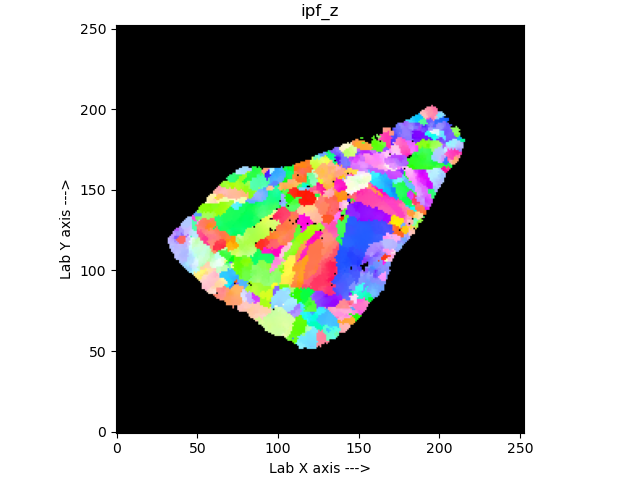

In [6]:
tmap_id11.plot('ipf_z')

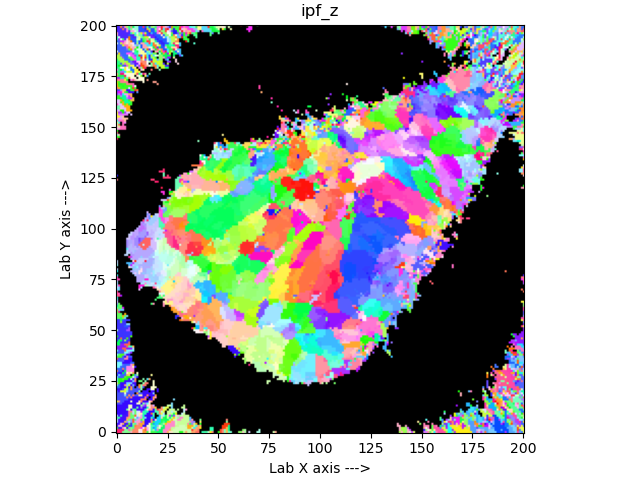

In [55]:
tmap_gpu.plot('ipf_z')

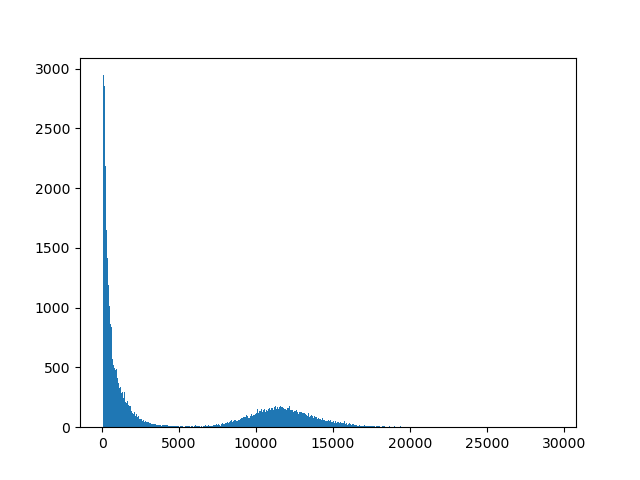

In [56]:
fig, ax = plt.subplots()
ax.hist(tmap_gpu.maps['occupancy'].flat, bins=500)
plt.show()

In [57]:
min_occ = 5000
good = tmap_gpu.maps['occupancy'] > min_occ

In [58]:
new_ubi = tmap_gpu.UBI.copy()

In [59]:
new_ubi = np.where(good[..., np.newaxis, np.newaxis], new_ubi, np.nan)

new_phase_ids = np.where(good, tmap_gpu.maps['phase_ids'], -1)

In [66]:
new_tmap = TensorMap(maps={
    'UBI': new_ubi,
    'phase_ids': new_phase_ids},
                     phases=tmap_gpu.phases,
                     steps=tmap_gpu.steps)

In [68]:
new_tmap.get_ipf_maps()

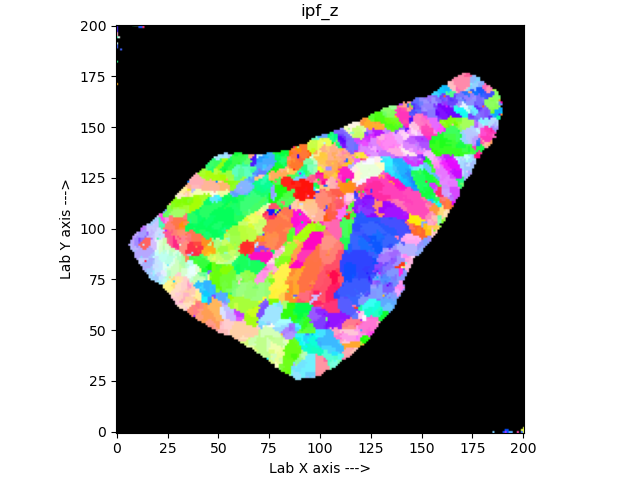

In [69]:
new_tmap.plot('ipf_z')

In [70]:
new_tmap.to_h5('tognan_mlem_tmap_10000_10_1.0_2.5_filtered.h5')